# **A Simple PINN**

### 1. Theory

The PDE residual $\delta_T$ is,

$$
\delta_T = \frac{dT}{dt} + \alpha (T_s - T)
$$

Our physics-informed loss function takes on the form $\mathcal{L} = \mathcal{L}_{\text{data}} \lambda \mathcal{L}_{\text{PDE}}$. In compacted notation, we have,

$$
\mathcal{L} = \frac{1}{B} \sum^{B}_{i=0} [T(t_i) - \hat{T}(t_i)]^2 + \lambda \delta_T^2
$$

where $\lambda$ is a hyperparameter that controls how much strongly the network considers the physics inspired loss.

### 2. Loading Data 

Let us first import the required modules,

In [107]:
# PyTorch imports,
import torch # <-- PyTorch
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader # <-- Wrappers for the data.
from torch.optim import Adam
import torch.nn.functional as F
from torchinfo import summary

# Importing,
import numpy as np
import matplotlib.pyplot as plt
import sys

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("Numpy version", np.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
Numpy version 1.26.4


Now we must create the a `Dataset` class for our data,

In [108]:
class MyDataset(Dataset):
    """Loads the data for the model."""

    def __init__(self, train=True):

        # Boolean logic for dataset,
        if train:
            Xy = np.load("train.npy")
        else:
            Xy = np.load("test.npy")

        # Extracting input and target,
        self.X, self.y = Xy[0], Xy[1]
        self.n_samples = Xy.shape[1]

        # Converting to Tensors (float32 type),
        self.X = torch.from_numpy(self.X.astype(np.float32)).unsqueeze(1)
        self.y = torch.from_numpy(self.y.astype(np.float32)).unsqueeze(1)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
    def __len__(self):
        return self.n_samples

We also create the `Scaler` class for scaling the data,

Creating the dataloader for the training data,

In [109]:
# Loading data,
train_data = MyDataset(train=True)
test_data = MyDataset(train=False)

# Creating dataloaders,
BATCH_SIZE = 16
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)

We inspect the data quickly,

In [110]:
for (X, y) in train_loader:
    print(f"X: {X.shape}, y: {y.shape}")
    break

X: torch.Size([16, 1]), y: torch.Size([16, 1])


### 3. Model Creation

Now we create tiny PINN architecture,

In [111]:
class Model(torch.nn.Module):
    """The neural network architecture."""

    def __init__(self):
        """Constuctor method. Builds the neural network."""
        super(Model, self).__init__()

        # Creating model layers,
        self.fc1 = Linear(in_features=1, out_features=32)
        self.fc2 = Linear(in_features=32, out_features=32)
        self.fc3 = Linear(in_features=32, out_features=32)
        self.fc4 = Linear(in_features=32, out_features=32)
        self.fc5 = Linear(in_features=32, out_features=1)

    def forward(self, x):
        """Defines the forward propagation of the neural network."""

        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        x = F.tanh(self.fc3(x))
        x = F.tanh(self.fc4(x))
        x = self.fc5(x)

        return x

Testing the forward propagation using `torchinfo`,

In [112]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 1))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [16, 1]                   --
├─Linear: 1-1                            [16, 32]                  64
├─Linear: 1-2                            [16, 32]                  1,056
├─Linear: 1-3                            [16, 32]                  1,056
├─Linear: 1-4                            [16, 32]                  1,056
├─Linear: 1-5                            [16, 1]                   33
Total params: 3,265
Trainable params: 3,265
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.01
Estimated Total Size (MB): 0.03

### 4. Loss Function

Now we create the physics informed loss function that encodes the physical laws via ODE residuals. 

In [113]:
def grad(outputs, inputs):
    """Computes the partial derivative of an output with respect to an input. Returns the gradient directly."""
    return torch.autograd.grad(
        outputs, 
        inputs, 
        grad_outputs=torch.ones_like(outputs), 
        create_graph=True
    )[0]

class CustomLoss(torch.nn.Module):
    """Implements the entire physics informed loss function."""
    def __init__(self, lambda_const, alpha=2.5, T_s=1):
        super(CustomLoss, self).__init__()
        self.lambda_const = lambda_const
        self.alpha = alpha
        self.T_s = T_s

    def forward(self, X_coll, y, y_pred, y_coll):
        """Forward propagation of the loss function."""

        # Data-driven loss,
        mse_loss = torch.mean((y_pred - y) ** 2)

        # Computing physics loss,
        dTdt = grad(y_coll, X_coll)
        residual = dTdt + self.alpha*(y_coll - self.T_s)
        physics_loss = torch.mean(residual**2)
        return mse_loss + self.lambda_const*physics_loss

### 5. Model Training (PHASE 1)

In [114]:
# Hyperparameters,
n_coll = 16
max_epochs = 1500
lr = 1e-3
lambda_param = 1e-2

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = CustomLoss(lambda_const=lambda_param)

"""TRAINING LOOP"""
train_losses = []
val_losses = []
for epoch in range(1, max_epochs+1):

    """================= TRAIN ================="""
    model.train() # <-- Training mode.
    train_running_loss = 0.0

    # Batch loop,
    for (X, y) in train_loader:
        optimiser.zero_grad() # Clear gradients,
        X, y = X.to(device), y.to(device) # Moving tensors to training device.
        y_pred = model(X) # Forward pass (data points).

        """================= COLOCATION POINTS ================="""
        X_coll = 5*torch.rand(n_coll ,1).to(device)
        X_coll = X_coll.unsqueeze(1).to(device).requires_grad_(True)
        y_coll = model(X_coll)

        loss = loss_fn(X_coll, y, y_pred, y_coll) # Computing loss.
        loss.backward() # Backward pass.
        optimiser.step() # Parameter update.

        # Tracking loss,
        train_running_loss += loss.item()

    train_loss = train_running_loss/len(train_loader)
    train_losses.append(train_loss)

    # Printing,
    print(f"Epoch {epoch} | training_loss: {train_loss:.6f}")

Training on: cpu
Epoch 1 | training_loss: 7.796299
Epoch 2 | training_loss: 4.033046
Epoch 3 | training_loss: 1.534219
Epoch 4 | training_loss: 1.185221
Epoch 5 | training_loss: 1.126540
Epoch 6 | training_loss: 0.944427
Epoch 7 | training_loss: 0.809428
Epoch 8 | training_loss: 0.717847
Epoch 9 | training_loss: 0.654415
Epoch 10 | training_loss: 0.496205
Epoch 11 | training_loss: 0.365432
Epoch 12 | training_loss: 0.233532
Epoch 13 | training_loss: 0.145496
Epoch 14 | training_loss: 0.107030
Epoch 15 | training_loss: 0.071844
Epoch 16 | training_loss: 0.045836
Epoch 17 | training_loss: 0.038038
Epoch 18 | training_loss: 0.033129
Epoch 19 | training_loss: 0.025470
Epoch 20 | training_loss: 0.020530
Epoch 21 | training_loss: 0.015574
Epoch 22 | training_loss: 0.015456
Epoch 23 | training_loss: 0.013517
Epoch 24 | training_loss: 0.010014
Epoch 25 | training_loss: 0.009581
Epoch 26 | training_loss: 0.007851
Epoch 27 | training_loss: 0.008019
Epoch 28 | training_loss: 0.007327
Epoch 29 | t

KeyboardInterrupt: 

Graphing the training loss,

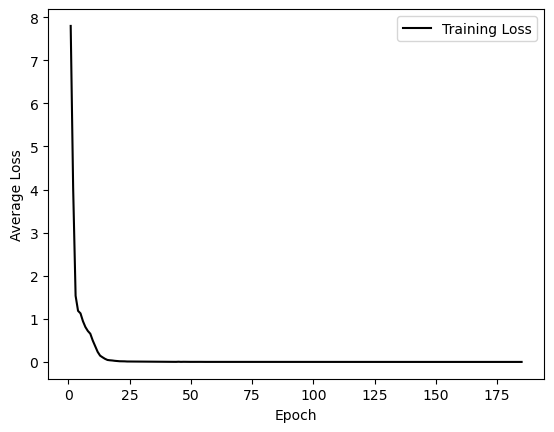

In [115]:
# Plotting,
epochs = np.arange(start=1, stop=len(train_losses)+1, step=1)
plt.plot(epochs, train_losses, color="black", label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

### 5. Model Predictions

We write a function for model inference,

In [116]:
def predict(model, dataloader, device="cpu"):
    """This function perform model inference."""

    model.eval() # <-- Switching to evaluation mode.
    X_input = []
    y_preds = []
    y_truth = []

    with torch.no_grad():
        for (X, y) in dataloader:

            # Switching devices,
            X = X.to(device).float()
            y = y.to(device).float()

            # Forward pass,
            y_pred = model(X)

            # Tracking,
            y_preds.append(y_pred.cpu())
            y_truth.append(y.cpu())
            X_input.append(X.cpu())

    # Converting into Numpy arrays,
    y_preds = np.squeeze(torch.cat(y_preds, dim=0).numpy())
    y_truth = np.squeeze(torch.cat(y_truth, dim=0).numpy())
    X_input = np.squeeze(torch.cat(X_input, dim=0).numpy())

    return X_input, y_preds, y_truth

Visualising the model predictions,


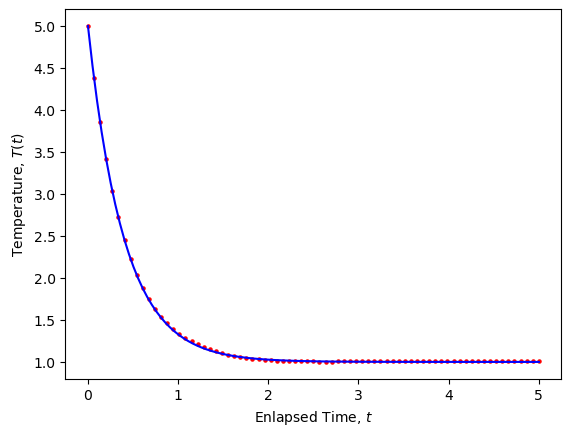

In [117]:
def solution(t, alpha, T_0, T_s):
    return T_s + (T_0 - T_s)*np.exp(-alpha*t)

# Parameters
alpha = 2.5
T_0 = 5
T_s = 1

# Computing analytical solution,
t = np.linspace(start=0, stop=5, num=100)
sol = solution(t, alpha, T_0, T_s)

# Computing model predictions,
X_test, y_preds, y_truth = predict(model, dataloader=test_loader, device=device)

# Plotting,
plt.plot(t, sol, color="blue")
plt.xlabel("Enlapsed Time, $t$")
plt.ylabel("Temperature, $T(t)$")
plt.scatter(X_test, y_preds, s=5, color="red")
plt.show()